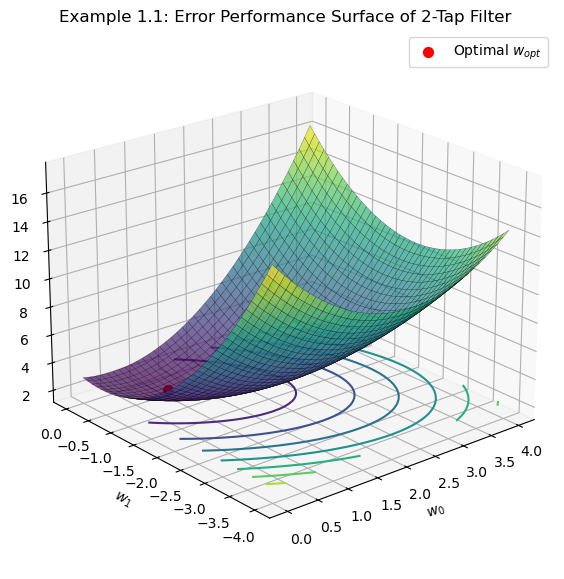

Optimal Wiener Weights (w_opt):
  w0 = 0.8363
  w1 = -0.7854
Minimum MSE (J_min): 2.2090


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


R = np.array([[1.1, 0.5], 
              [0.5, 1.1]])
p = np.array([[0.5272], 
              [-0.4458]])
dn_var = 3.0


w0 = np.arange(0, 4.1, 0.1)
w1 = np.arange(-4, 0.1, 0.1)


W0, W1 = np.meshgrid(w0, w1)
J = np.zeros(W0.shape)

for m in range(len(w0)):
    for n in range(len(w1)):
        w = np.array([[w0[m]], [w1[n]]])
        cost = dn_var - 2 * np.dot(p.T, w) + np.dot(w.T, np.dot(R, w))
        J[n, m] = cost[0, 0]


w_opt = np.linalg.inv(R).dot(p)
J_min = dn_var - np.dot(p.T, w_opt)[0, 0]


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')


surf = ax.plot_surface(W0, W1, J, cmap='viridis', alpha=0.7, edgecolor='k', linewidth=0.2)


ax.contour(W0, W1, J, zdir='z', offset=np.min(J), cmap='viridis')


ax.scatter(w_opt[0, 0], w_opt[1, 0], np.min(J), color='red', s=50, marker='o', label='Optimal $w_{opt}$')


ax.view_init(elev=22, azim=-130)


ax.set_xlabel('$w_0$')
ax.set_ylabel('$w_1$')
ax.set_zlabel('MSE ($J$)')
ax.set_title('Example 1.1: Error Performance Surface of 2-Tap Filter')
plt.legend()
plt.show()


print(f"Optimal Wiener Weights (w_opt):\n  w0 = {w_opt[0, 0]:.4f}\n  w1 = {w_opt[1, 0]:.4f}")
print(f"Minimum MSE (J_min): {J_min:.4f}")

In [4]:
import numpy as np

# Original 256-tap impulse response values from h1.dat
h1_data = np.array([
    -0.000708921, 0.00134117, -0.00148114, 0.00181585, -0.00199982, 0.00212473,
    -0.00232657, 0.00233689, -0.00237134, 0.00233577, -0.00205025, 0.00168909,
    -0.000948031, 0.000236641, -0.00579454, -0.519731, -0.0237539, -0.192709,
    0.277037, 0.255099, 0.269953, 0.19235, 0.0687358, 0.118808, 0.1182,
    0.0295905, -0.078145, -0.0250391, -0.0593436, -0.0558066, -0.0356399,
    -0.0254799, -0.0510084, -0.0826949, -0.122139, -0.0454484, -0.0562023,
    0.0124346, -0.0214663, -0.0459587, -0.0703649, -0.0227346, -0.00889847,
    -0.034636, -0.0402683, 0.0163966, 0.00349723, 0.00933556, -0.0148983,
    -0.012728, 0.00578419, 0.0385114, 0.0316233, 0.0257457, 0.003422,
    -0.00427498, 0.0160274, 0.0438191, 0.00304696, 0.030381, -0.00823772,
    0.0585535, 0.0206018, 0.0238726, 0.0489467, 0.0628626, 0.0680897,
    0.0190338, 0.0131552, -0.0440507, -0.044864, -0.0345377, -0.0163884,
    -0.0224183, 0.0071838, 0.00577622, 0.00153603, -0.0159681, 0.0016022,
    -0.0123713, -0.00882457, -0.00141933, -0.00704326, -0.0135683, -0.00561755,
    0.0101046, 0.0137791, 0.00567888, 0.0233987, -0.0367884, -0.0445958,
    0.000846253, 0.030772, 0.0298113, 0.0258122, 0.00128464, -0.0525284,
    -0.0641487, -0.0395876, -0.0253521, 0.0446303, 0.0748973, 0.0478575,
    0.014876, 0.0261288, -0.00127511, -0.0111423, -0.0159452, -0.0253402,
    -0.00757779, 0.000858746, -0.00768724, -0.00782599, -0.00906777, -0.0156146,
    -0.0143377, -0.0437869, -0.0217489, -0.0255929, -0.0130375, -0.00794929,
    0.0178786, 0.00439428, 0.00609518, 0.00974637, 0.0166263, -0.0125864,
    -0.0234728, -0.0293175, 0.0441643, 0.0599379, 0.046634, 0.00798373,
    -0.0177256, -0.000833382, 0.0010749, 0.0232351, 0.0186037, 0.0240741,
    -0.00835556, -0.00803383, 0.00273631, -0.00745814, 0.0132184, 0.0237407,
    0.0260036, 0.00237208, -0.00734865, -0.00349003, 0.00116811, 0.0170402,
    -0.0173784, -0.0358136, -0.0331384, -0.0147108, -0.00730376, -0.0339649,
    -0.0337807, -0.0262045, -0.00651208, 0.0146617, 0.000353269, -0.0164852,
    -0.0093149, -0.0142298, 0.0356143, 0.0318273, -0.000935437, -0.00709456,
    0.00994571, 0.00969173, 0.0172775, 0.0185947, -0.0041256, -0.0110373,
    0.0123295, 0.0376464, 0.010939, -0.00168267, 0.00996989, -0.00659403,
    -0.0173512, -0.0130058, -0.0175135, -0.0228318, -0.0176264, 0.0102606,
    0.0126546, -0.0120021, -0.000911264, 0.0246961, 0.0255624, -0.00809881,
    -0.0138994, 0.00108146, 0.0219628, 0.0128455, 0.0199173, 0.0134614,
    0.0156368, -0.00119792, -0.0159582, -0.00484232, 0.00224707, 0.00352621,
    -0.0253506, -0.0272833, -0.0121462, 0.00432912, 0.00365799, -0.00960026,
    -0.0180127, -0.0188592, -0.00944672, -0.0103561, -0.0141174, -0.017916,
    -0.0142349, -0.0267402, -0.0180766, -0.00135964, 0.0250306, 0.0450874,
    0.0308754, 0.00457823, -0.00204818, 0.0212093, 0.0115935, 0.00991013,
    0.00921016, 0.00325272, 0.00144573, 0.00477798, 0.0198763, -0.0039066,
    -0.00516348, 0.00712721, 0.0170348, -0.0114242, -0.0172962, -0.00419164,
    0.0116897, 0.0213696, 0.00795252, 0.0074573, -0.00842253, -0.000767162,
    0.000200447, 0.00157383, -0.0037627, 0.00592311, -0.0086734, -0.0222886,
    -0.0265532, 0.00271988, -0.00507369, -0.00362365, -0.00392368, 0.000496115,
    0.00390617, -0.00688577, 0.00954549, -4.12367e-05, -0.016446, -0.0267001
])

# Save array to local text file 'h1.dat'
np.savetxt('h1.dat', h1_data)
print(f"Successfully saved 'h1.dat' with {len(h1_data)} taps!")

Successfully saved 'h1.dat' with 265 taps!


LMS, step size = 0.00100
Step size check: mu (0.001) < max_mu (0.00390) -> STABLE
Total time = 0.188 mins


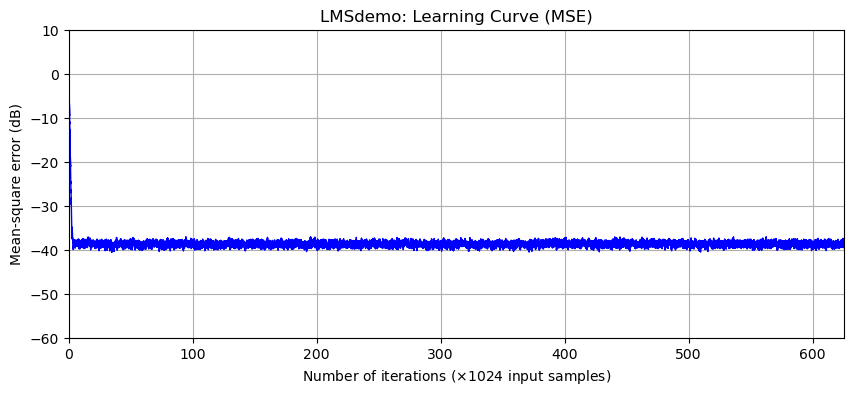

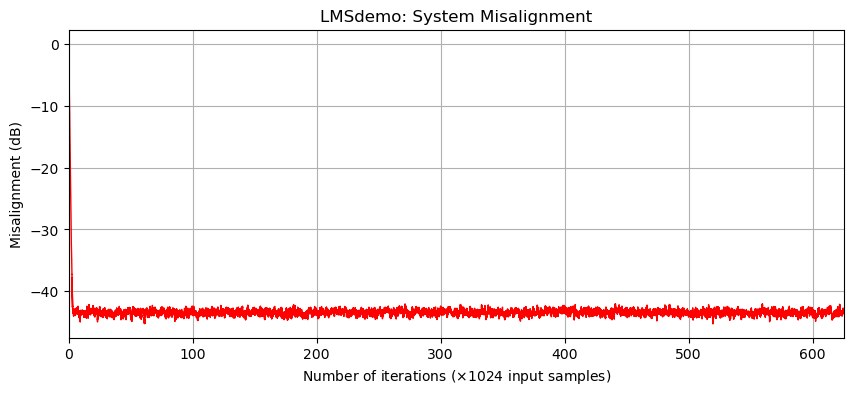

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.signal import lfilter

# 1. LMS Class
class LMSDemoFilter:
    def __init__(self, num_taps: int, mu: float, unknown_sys: np.ndarray):
        self.num_taps = num_taps
        self.mu = mu
        self.w = np.zeros(num_taps)
        self.b = unknown_sys
        self.b_norm_sq = np.sum(self.b ** 2)

    def adapt(self, u: np.ndarray, d: np.ndarray):
        n_samples = len(u)
        y = np.zeros(n_samples)
        e = np.zeros(n_samples)
        eml = np.zeros(n_samples)
        x_buf = np.zeros(self.num_taps)

        for n in range(n_samples):
            x_buf[1:] = x_buf[:-1]
            x_buf[0] = u[n]

            y[n] = np.dot(self.w, x_buf)
            e[n] = d[n] - y[n]

            eml[n] = np.sum((self.b - self.w) ** 2) / (self.b_norm_sq + 1e-12)
            self.w += 2 * self.mu * e[n] * x_buf

        return y, e, eml

# 2. Simulation Execution with Loaded h1.dat
np.random.seed(42)

mu = 0.001          
M = 256             
iterations = 8 * 80000  

# Load exact impulse response
b = np.loadtxt('h1.dat')[:M]

print(f"LMS, step size = {mu:.5f}")
t_start = time.time()

un = np.random.normal(0, 1.0, iterations)
dn = np.convolve(un, b, mode='full')[:iterations] + np.random.normal(0, 0.01, iterations)

max_mu = 1.0 / (M * np.var(un))
print(f"Step size check: mu ({mu}) < max_mu ({max_mu:.5f}) -> {'STABLE' if mu < max_mu else 'UNSTABLE'}")

lms = LMSDemoFilter(num_taps=M, mu=mu, unknown_sys=b)
yn, en, eml = lms.adapt(u=un, d=dn)

print(f"Total time = {(time.time() - t_start) / 60.0:.3f} mins")

# 3. Plotting
q = 0.99
err_sqr = en ** 2
mse = lfilter([1 - q], [1, -q], err_sqr)

x_axis = np.arange(len(mse)) / 1024.0

plt.figure(figsize=(10, 4))
plt.plot(x_axis, 10 * np.log10(mse + 1e-12), color='blue', linewidth=1)
plt.xlim([0, iterations / 1024.0])
plt.ylim([-60, 10])
plt.xlabel(r'Number of iterations ($\times 1024$ input samples)')
plt.ylabel('Mean-square error (dB)')
plt.title('LMSdemo: Learning Curve (MSE)')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(x_axis, 10 * np.log10(eml + 1e-12), color='red', linewidth=1)
plt.xlim([0, iterations / 1024.0])
plt.xlabel(r'Number of iterations ($\times 1024$ input samples)')
plt.ylabel('Misalignment (dB)')
plt.title('LMSdemo: System Misalignment')
plt.grid(True)
plt.show()

NLMS, step size = 0.10
Total time = 0.216 mins


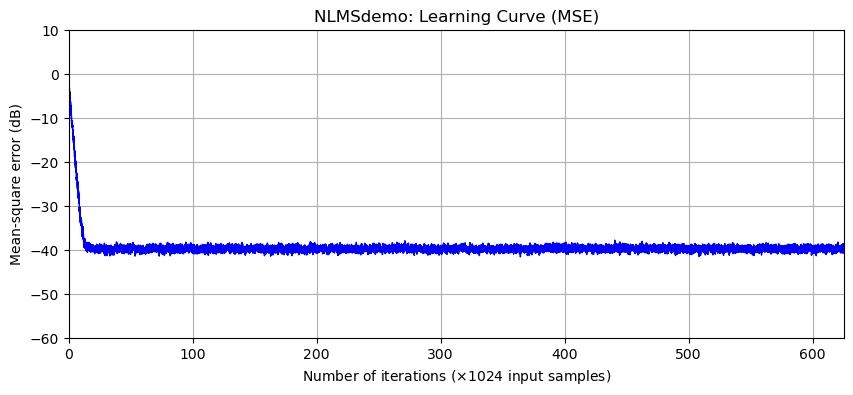

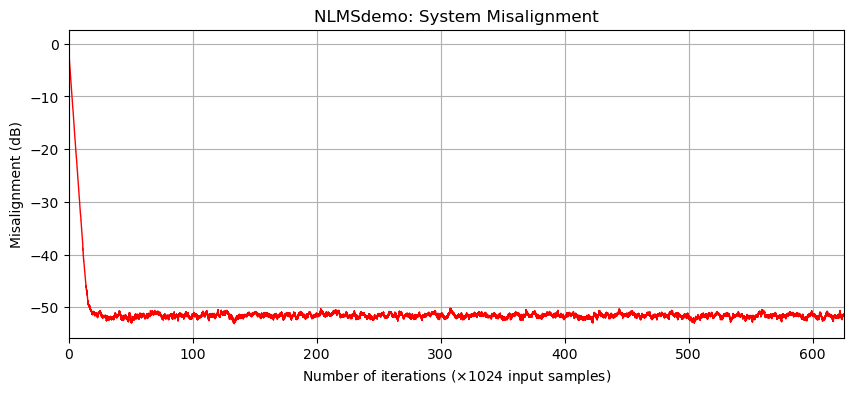

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.signal import lfilter


class NLMSDemoFilter:
    def __init__(self, num_taps: int, mu: float, unknown_sys: np.ndarray, psi: float = 1e-6):
        self.num_taps = num_taps
        self.mu = mu
        self.psi = psi 
        self.w = np.zeros(num_taps)
        self.b = unknown_sys
        self.b_norm_sq = np.sum(self.b ** 2)

    def adapt(self, u: np.ndarray, d: np.ndarray):
        n_samples = len(u)
        y = np.zeros(n_samples)
        e = np.zeros(n_samples)
        eml = np.zeros(n_samples)
        x_buf = np.zeros(self.num_taps)

        for n in range(n_samples):
            
            x_buf[1:] = x_buf[:-1]
            x_buf[0] = u[n]

           
            y[n] = np.dot(self.w, x_buf)
            e[n] = d[n] - y[n]

            
            eml[n] = np.sum((self.b - self.w) ** 2) / (self.b_norm_sq + 1e-12)

            
            norm_x_sq = np.dot(x_buf, x_buf)
            self.w += (self.mu / (norm_x_sq + self.psi)) * e[n] * x_buf

        return y, e, eml



np.random.seed(42)  

mu = 0.1            
M = 256             
iterations = 8 * 80000  


b = np.loadtxt('h1.dat')[:M]

print(f"NLMS, step size = {mu:.2f}")
t_start = time.time()


un = np.random.normal(0, 1.0, iterations)
dn = np.convolve(un, b, mode='full')[:iterations] + np.random.normal(0, 0.01, iterations)


nlms = NLMSDemoFilter(num_taps=M, mu=mu, unknown_sys=b)
yn, en, eml = nlms.adapt(u=un, d=dn)

t_elapsed = (time.time() - t_start) / 60.0
print(f"Total time = {t_elapsed:.3f} mins")



q = 0.99
err_sqr = en ** 2
mse = lfilter([1 - q], [1, -q], err_sqr)

x_axis = np.arange(len(mse)) / 1024.0


plt.figure(figsize=(10, 4))
plt.plot(x_axis, 10 * np.log10(mse + 1e-12), color='blue', linewidth=1)
plt.xlim([0, iterations / 1024.0])
plt.ylim([-60, 10])
plt.xlabel(r'Number of iterations ($\times 1024$ input samples)')
plt.ylabel('Mean-square error (dB)')
plt.title('NLMSdemo: Learning Curve (MSE)')
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(x_axis, 10 * np.log10(eml + 1e-12), color='red', linewidth=1)
plt.xlim([0, iterations / 1024.0])
plt.xlabel(r'Number of iterations ($\times 1024$ input samples)')
plt.ylabel('Misalignment (dB)')
plt.title('NLMSdemo: System Misalignment')
plt.grid(True)
plt.show()

Running LMS AEC (mu = 0.0001)...
LMS completed in 1.40s
Running NLMS AEC (mu = 0.10)...
NLMS completed in 0.67s


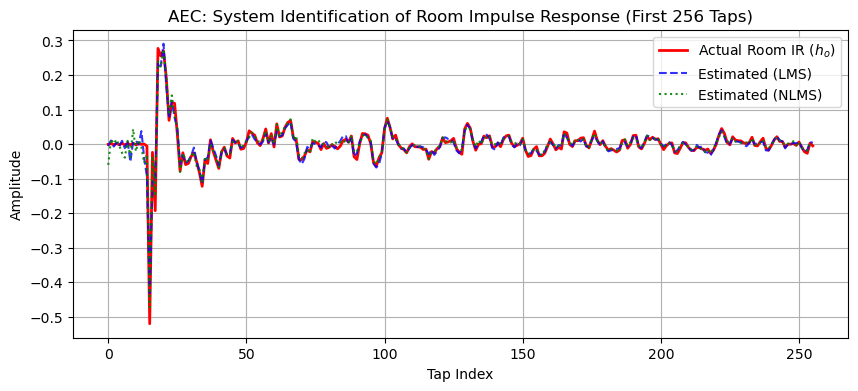

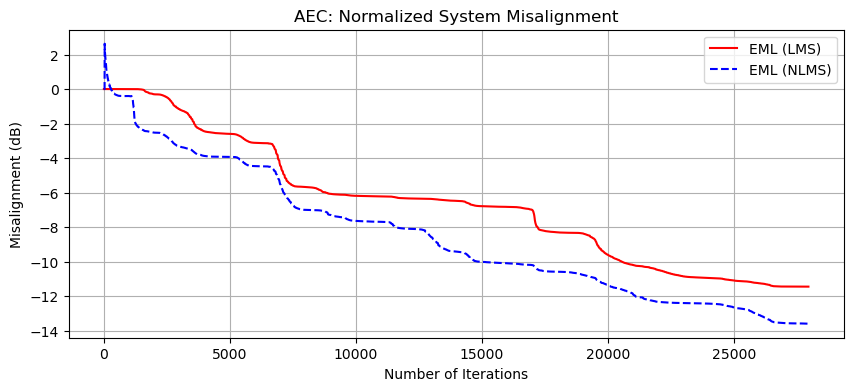

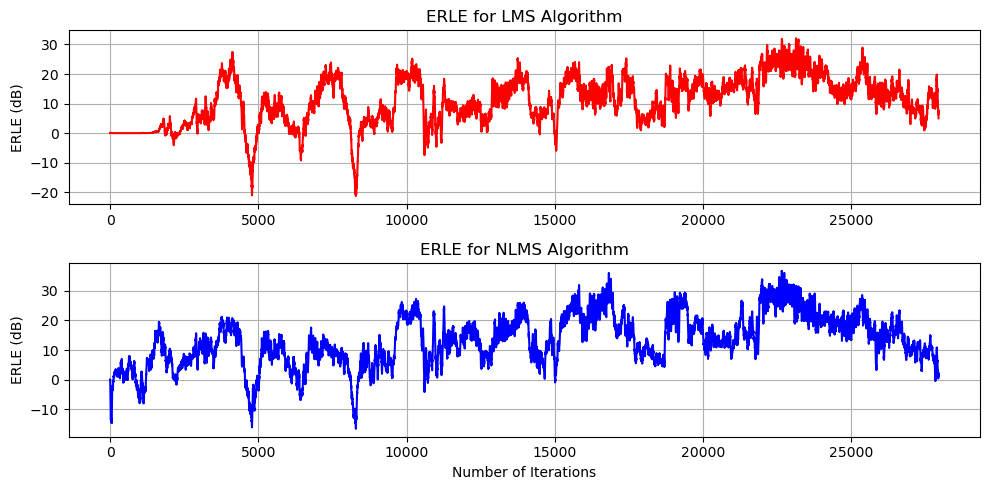

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.signal import lfilter


class AEC_LMS:
    def __init__(self, M: int, mu: float, h_true: np.ndarray):
        self.M = M
        self.mu = mu
        self.w = np.zeros(M)
        self.h_true = h_true
        self.norm_h_sq = np.sum(h_true ** 2)

    def adapt(self, u: np.ndarray, d: np.ndarray):
        N = len(u)
        y, e, eml = np.zeros(N), np.zeros(N), np.zeros(N)
        x_buf = np.zeros(self.M)

        for n in range(N):
            x_buf[1:] = x_buf[:-1]
            x_buf[0] = u[n]

            y[n] = np.dot(self.w, x_buf)
            e[n] = d[n] - y[n]

          
            err_w = self.h_true - self.w
            eml[n] = np.sum(err_w ** 2) / (self.norm_h_sq + 1e-12)

            
            self.w += 2 * self.mu * e[n] * x_buf
            
            self.w = np.nan_to_num(self.w, nan=0.0, posinf=1e3, neginf=-1e3)

        return y, e, eml, self.w

class AEC_NLMS:
    def __init__(self, M: int, mu: float, h_true: np.ndarray, psi: float = 1e-6):
        self.M = M
        self.mu = mu
        self.psi = psi
        self.w = np.zeros(M)
        self.h_true = h_true
        self.norm_h_sq = np.sum(h_true ** 2)

    def adapt(self, u: np.ndarray, d: np.ndarray):
        N = len(u)
        y, e, eml = np.zeros(N), np.zeros(N), np.zeros(N)
        x_buf = np.zeros(self.M)

        for n in range(N):
            x_buf[1:] = x_buf[:-1]
            x_buf[0] = u[n]

            y[n] = np.dot(self.w, x_buf)
            e[n] = d[n] - y[n]

            err_w = self.h_true - self.w
            eml[n] = np.sum(err_w ** 2) / (self.norm_h_sq + 1e-12)

            norm_x_sq = np.dot(x_buf, x_buf)
            self.w += (self.mu / (norm_x_sq + self.psi)) * e[n] * x_buf

        return y, e, eml, self.w



np.random.seed(42)


try:
    h1_full = np.loadtxt('h1.dat')
    if len(h1_full) < 1024:
        ho = np.pad(h1_full, (0, 1024 - len(h1_full)))
    else:
        ho = h1_full[:1024]
except OSError:
    print("Notice: 'h1.dat' not found. Generating synthetic room impulse response.")
    ho = np.exp(-0.005 * np.arange(1024)) * np.random.randn(1024)

M = 1024  


try:
    from scipy.io import wavfile
    fsf, far_end = wavfile.read('far.wav')
    if far_end.ndim > 1:
        far_end = far_end[:, 0]
    far_end = far_end.astype(np.float64)
    far_end /= np.max(np.abs(far_end))
except OSError:
    print("Notice: 'far.wav' not found. Generating synthetic speech burst signal.")
    t = np.linspace(0, 4, 32000)
    far_end = np.sin(2 * np.pi * 300 * t) * (np.sin(2 * np.pi * 2 * t) > 0)
    far_end += 0.05 * np.random.randn(len(t))


un = far_end / (np.std(far_end) + 1e-12)
ITER = len(un)


vn = 0.01 * np.random.randn(ITER)
near_end = vn.copy()


echo_signal = np.convolve(un, ho, mode='full')[:ITER]
dn = echo_signal + near_end


print("Running LMS AEC (mu = 0.0001)...")
t0 = time.time()
lms_aec = AEC_LMS(M=M, mu=0.0001, h_true=ho)
ylms, enlms, EMLlms, w_lms = lms_aec.adapt(un, dn)
print(f"LMS completed in {(time.time() - t0):.2f}s")

print("Running NLMS AEC (mu = 0.10)...")
t0 = time.time()
nlms_aec = AEC_NLMS(M=M, mu=0.10, h_true=ho)
ynlms, ennlms, EMLnlms, w_nlms = nlms_aec.adapt(un, dn)
print(f"NLMS completed in {(time.time() - t0):.2f}s")



plt.figure(figsize=(10, 4))
plt.plot(ho[:256], 'r', label='Actual Room IR ($h_o$)', linewidth=2)
plt.plot(w_lms[:256], 'b--', label='Estimated (LMS)', alpha=0.8)
plt.plot(w_nlms[:256], 'g:', label='Estimated (NLMS)', alpha=0.9)
plt.title('AEC: System Identification of Room Impulse Response (First 256 Taps)')
plt.xlabel('Tap Index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(10 * np.log10(EMLlms + 1e-12), 'r', label='EML (LMS)')
plt.plot(10 * np.log10(EMLnlms + 1e-12), 'b--', label='EML (NLMS)')
plt.title('AEC: Normalized System Misalignment')
plt.xlabel('Number of Iterations')
plt.ylabel('Misalignment (dB)')
plt.legend()
plt.grid(True)
plt.show()


win = 50
dn_sqr = (dn - near_end) ** 2
UDerrlms_sqr = np.maximum((enlms - near_end) ** 2, 1e-12)
UDerrnlms_sqr = np.maximum((ennlms - near_end) ** 2, 1e-12)

erle_lms = 10 * np.log10((dn_sqr + 1e-12) / UDerrlms_sqr)
erle_nlms = 10 * np.log10((dn_sqr + 1e-12) / UDerrnlms_sqr)

# Smooth ERLE curves
erle_lms_smooth = np.convolve(erle_lms, np.ones(win)/win, mode='same')
erle_nlms_smooth = np.convolve(erle_nlms, np.ones(win)/win, mode='same')

plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.plot(erle_lms_smooth, 'r')
plt.title('ERLE for LMS Algorithm')
plt.ylabel('ERLE (dB)')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(erle_nlms_smooth, 'b')
plt.title('ERLE for NLMS Algorithm')
plt.xlabel('Number of Iterations')
plt.ylabel('ERLE (dB)')
plt.grid(True)

plt.tight_layout()
plt.show()